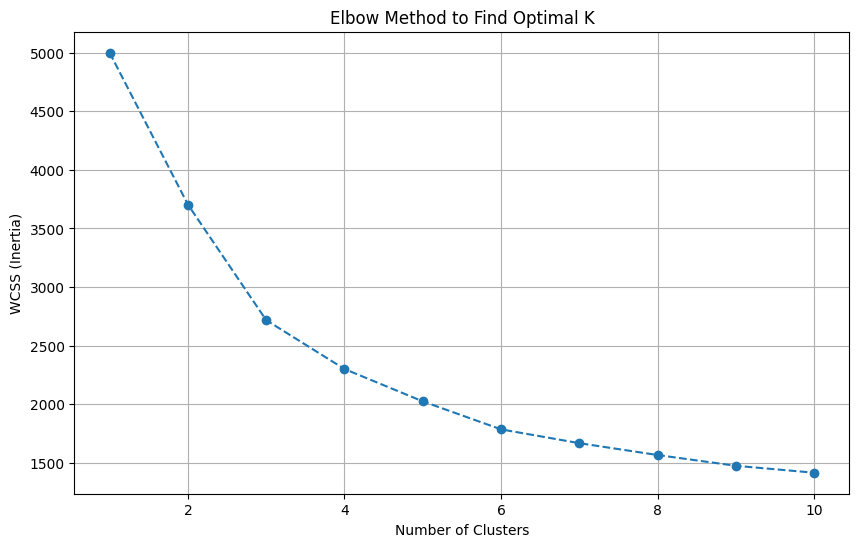

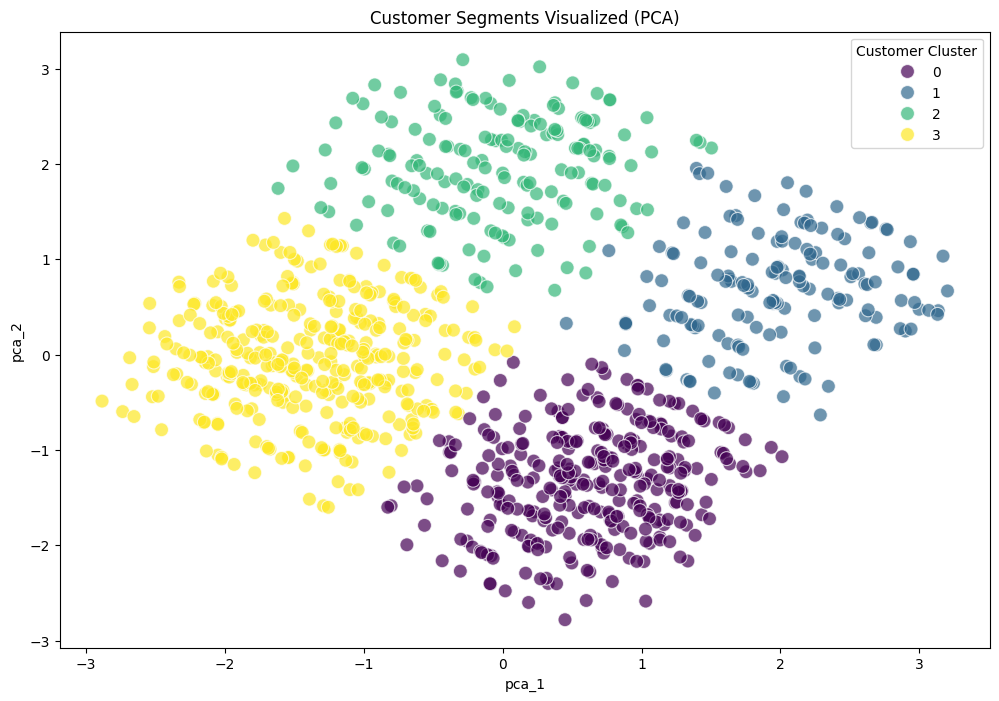

--- Segment Persona Summary ---
               age  stress_level  sleep_quality  interest_OSP  \
Cluster                                                         
0        62.006410      3.907051       5.605769      3.099359   
1        61.625806      8.883871       5.400000      7.470968   
2        34.610465      8.813953       5.534884      7.267442   
3        34.880886      3.786704       5.448753      2.905817   

         interest_Ambrotose  
Cluster                      
0                  7.993590  
1                  7.987097  
2                  3.337209  
3                  3.373961  

[SUCCESS] Segmentation complete. Results saved to data/segmented_customer_data.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load the dataset
# This data was generated in 01_data_generation and verified in 02_EDA
df = pd.read_csv('../data/synthetic_health_data.csv')

# 2. Feature Selection
# We select the core health indicators and product interest scores for clustering
features = ['age', 'stress_level', 'sleep_quality', 'interest_OSP', 'interest_Ambrotose']
X = df[features]

# 3. Data Normalization (Industrial Standard)
# Crucial: Age (20-74) and health scores (1-10) have different scales. 
# We normalize them to ensure each feature carries equal weight in the distance calculation.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Finding Optimal Clusters (The Elbow Method)
# This step mathematically justifies the choice of 'k' (number of groups).
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plotting the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# 5. Execute K-Means++ Clustering
# Based on the elbow plot, k=4 is the optimal number of distinct segments.
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. Dimensionality Reduction & Visualization (PCA)
# Humans cannot visualize 5D space. PCA compresses these into 2 main components (PCA1, PCA2).
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='Cluster', palette='viridis', s=100, alpha=0.7)
plt.title('Customer Segments Visualized (PCA)')
plt.legend(title='Customer Cluster')
plt.show()

# 7. Knowledge Discovery: Persona Summary
# This output provides the actionable business insights for the IA (Independent Associate).
persona_summary = df.groupby('Cluster')[features].mean()
print("--- Segment Persona Summary ---")
print(persona_summary)

# 8. Save the segmented data for the Recommendation phase (Notebook 04)
df.to_csv('../data/segmented_customer_data.csv', index=False)
print("\n[SUCCESS] Segmentation complete. Results saved to data/segmented_customer_data.csv")